**TGSS DATA ANALYSIS PROJECT**


**INTRODUCTION**

This project explores demographic and socioeconomic patterns is in The Turkish General Social Survey(TGSS) dataset.

**GOAL**

-Understand basic distributions of age,gender,education and settlement.

-Prepare data for further analyses.

-Create visualizations and insights.

**TOOLS USED**

Python,Pandas,Numpy,Matplotlib,Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load TGSS dataset

In [3]:
df=pd.read_csv("TGSS2024.csv")

In [4]:
#Quick Overview

In [5]:
df.head()

,id,age,agegroup,gender,area14,areasame,degree,edulit,enrolled,enrolledlv,...,likesma,likespa,likesfre,judgefre,oldincyou,qform,method,degurba,nuts1,nuts2
0,1,44.0,3.0,2.0,4.0,2.0,2.0,-90.0,2.0,-90.0,...,-90.0,-90.0,-90.0,-90.0,-90.0,3.0,1.0,3.0,1.0,1.0
1,2,41.0,3.0,2.0,2.0,2.0,4.0,-90.0,2.0,-90.0,...,-90.0,-90.0,-90.0,-90.0,-90.0,1.0,2.0,3.0,6.0,3.0
2,3,23.0,1.0,2.0,2.0,1.0,6.0,-90.0,2.0,-90.0,...,5.0,5.0,5.0,5.0,3.0,1.0,2.0,3.0,8.0,10.0
3,4,19.0,1.0,2.0,3.0,1.0,4.0,-90.0,1.0,5.0,...,4.0,5.0,4.0,4.0,4.0,1.0,1.0,3.0,3.0,7.0
4,5,47.0,4.0,1.0,4.0,1.0,4.0,-90.0,2.0,-90.0,...,-90.0,-90.0,-90.0,-90.0,-90.0,2.0,2.0,1.0,8.0,10.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2615 entries, 0 to 2614
Columns: 664 entries, id to nuts2
dtypes: float64(663), int64(1)
memory usage: 13.2 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2615.0,1308.000000,755.029801,1.0,654.5,1308.0,1961.5,2615.0
age,2615.0,40.294455,15.272772,18.0,27.0,39.0,51.0,100.0
agegroup,2615.0,3.048948,1.527575,1.0,2.0,3.0,4.0,6.0
gender,2615.0,1.491013,0.500015,1.0,1.0,1.0,2.0,2.0
area14,2615.0,1.980497,4.984291,-99.0,1.0,2.0,4.0,4.0
...,...,...,...,...,...,...,...,...
qform,2615.0,2.009560,0.822122,1.0,1.0,2.0,3.0,3.0
method,2615.0,1.617208,0.486161,1.0,1.0,2.0,2.0,2.0
degurba,2615.0,2.507457,0.758932,1.0,2.0,3.0,3.0,3.0
nuts1,2615.0,5.697132,3.570587,1.0,3.0,5.0,8.0,12.0


The dataset contains survey responses with numeric and categorical variables.Most of the columns are stored as integer or float types
because categorical values are coded numerically.

Before starting the analysis ,I will perform basic data cleaning and feature engineering,specifically, I plan to create new label columns
to represent categories such as gender,agegroup,degree(education level),degurba(settlement type)

Additionally,I will check for missing values and special codes(such as -99 or similar values) that may represent missing or undefined responses.

In [8]:
#Check for missing values 

In [9]:
df.isnull().sum()

id          0
age         0
agegroup    0
gender      0
area14      0
           ..
qform       0
method      0
degurba     0
nuts1       0
nuts2       0
Length: 664, dtype: int64

In [10]:
#replace special missing value codes with NaN and I will check again with head()

In [11]:
df.replace([-87,-88,-89,-90,-97,-98,-99,999],np.nan,inplace=True)

In [12]:
df.head()

,id,age,agegroup,gender,area14,areasame,degree,edulit,enrolled,enrolledlv,...,likesma,likespa,likesfre,judgefre,oldincyou,qform,method,degurba,nuts1,nuts2
0,1.0,44.0,3.0,2.0,4.0,2.0,2.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,1.0,3.0,1.0,1.0
1,2.0,41.0,3.0,2.0,2.0,2.0,4.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,2.0,3.0,6.0,3.0
2,3.0,23.0,1.0,2.0,2.0,1.0,6.0,NaN,2.0,NaN,...,5.0,5.0,5.0,5.0,3.0,1.0,2.0,3.0,8.0,10.0
3,4.0,19.0,1.0,2.0,3.0,1.0,4.0,NaN,1.0,5.0,...,4.0,5.0,4.0,4.0,4.0,1.0,1.0,3.0,3.0,7.0
4,5.0,47.0,4.0,1.0,4.0,1.0,4.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1.0,8.0,10.0


In [13]:
#I will check about duplicate values

In [14]:
df.duplicated().sum()

np.int64(0)

I completed the basic cleaning steps on the dataset, checked for missing values, replaced abnormal values with NaN, and double-checked. I checked for duplicate values, and my data is now ready for the feature engineering process. Now, I'm starting a short EDA process,Next I will apply feature engineering to the four data columns I want to analyze.

In [15]:
df.describe()

,id,age,agegroup,gender,area14,areasame,degree,edulit,enrolled,enrolledlv,...,likesma,likespa,likesfre,judgefre,oldincyou,qform,method,degurba,nuts1,nuts2
count,2614.000000,2615.000000,2615.000000,2615.000000,2608.000000,2605.000000,2615.000000,113.000000,2609.000000,410.000000,...,799.000000,813.000000,805.000000,813.000000,767.000000,2615.000000,2615.000000,2615.000000,2615.000000,2615.000000
mean,1308.118210,40.294455,3.048948,1.491013,2.230445,1.448752,3.852390,1.566372,1.838252,4.160976,...,4.255319,4.654367,4.170186,4.131611,2.740548,2.009560,1.617208,2.507457,5.697132,9.515488
std,755.150059,15.272772,1.527575,0.500015,1.223178,0.497462,1.514407,0.497783,0.368290,1.064400,...,1.056022,0.719090,0.789928,1.003024,1.105038,0.822122,0.486161,0.758932,3.570587,7.110913
min,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,654.250000,27.000000,2.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000,3.000000,...,4.000000,5.000000,4.000000,4.000000,2.000000,1.000000,1.000000,2.000000,3.000000,3.000000
50%,1308.500000,39.000000,3.000000,1.000000,2.000000,1.000000,4.000000,2.000000,2.000000,4.000000,...,5.000000,5.000000,4.000000,4.000000,3.000000,2.000000,2.000000,3.000000,5.000000,8.000000
75%,1961.750000,51.000000,4.000000,2.000000,4.000000,2.000000,5.000000,2.000000,2.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,2.000000,3.000000,8.000000,15.000000
max,2615.000000,100.000000,6.000000,2.000000,4.000000,2.000000,8.000000,2.000000,2.000000,7.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,2.000000,3.000000,12.000000,26.000000


In [16]:
# The age column has a value of 100; I will verify this value to make sure it is correct.I will plot a boxplot to check for outlier values.

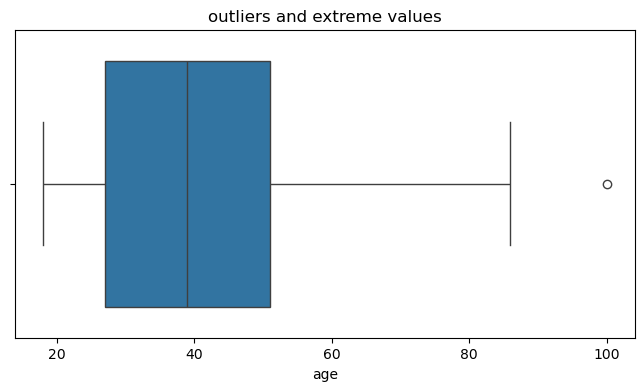

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["age"])
plt.title("outliers and extreme values")
plt.show()

That point is an outlier; it is very far from the mean. Since it is a single data point, it does not disrupt the analysis and can be retained; however, if a stricter filter is required, this record can be excluded using: df=df[df["age"]<100].For now I am keeping it to preserve the original sample size

Before proceeding to the feature engineering stage, I perform a final correlation check and gain a brief understanding of the relationships between the variables.

In [18]:
df.corr(numeric_only=True)

,id,age,agegroup,gender,area14,areasame,degree,edulit,enrolled,enrolledlv,...,likesma,likespa,likesfre,judgefre,oldincyou,qform,method,degurba,nuts1,nuts2
id,1.000000,0.017031,0.019842,-0.000588,-0.008308,0.003373,-0.004147,-0.075042,0.000415,-0.024437,...,0.035404,0.020872,-0.024525,0.031381,0.009978,0.000787,0.010795,-0.027117,-0.010600,-0.018447
age,0.017031,1.000000,0.980059,-0.133106,0.182137,0.056858,-0.273510,0.146532,0.379658,0.050322,...,0.009210,0.029847,-0.013352,0.040416,-0.174166,0.000964,0.246007,-0.129699,-0.120238,-0.014586
agegroup,0.019842,0.980059,1.000000,-0.126640,0.177075,0.063657,-0.267581,0.113561,0.386421,0.006312,...,0.039822,0.025705,-0.000450,0.052833,-0.162144,0.004197,0.244167,-0.119108,-0.122196,-0.016517
gender,-0.000588,-0.133106,-0.126640,1.000000,-0.008761,0.092704,-0.091174,0.155684,-0.035658,-0.093920,...,0.087930,-0.015837,-0.005336,-0.084941,-0.090284,-0.007701,-0.052713,0.095191,-0.019953,-0.051310
area14,-0.008308,0.182137,0.177075,-0.008761,1.000000,-0.018534,-0.268398,-0.020503,0.116919,-0.119693,...,-0.028476,-0.030119,0.020067,-0.048512,-0.070032,0.019242,0.212005,-0.397273,0.159832,0.195951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
qform,0.000787,0.000964,0.004197,-0.007701,0.019242,-0.004482,0.011581,-0.090196,-0.001212,-0.035228,...,0.025046,0.074802,-0.022601,0.016300,0.024708,1.000000,-0.011898,-0.010231,0.009849,-0.011837
method,0.010795,0.246007,0.244167,-0.052713,0.212005,-0.084843,-0.314753,0.145534,0.136539,-0.172248,...,0.131243,0.133111,0.055764,0.067439,0.023117,-0.011898,1.000000,-0.228142,0.228277,0.261268
degurba,-0.027117,-0.129699,-0.119108,0.095191,-0.397273,0.148541,0.184026,-0.104605,-0.053512,0.124605,...,-0.093344,-0.051606,-0.007963,0.012483,-0.012879,-0.010231,-0.228142,1.000000,-0.196385,-0.295106
nuts1,-0.010600,-0.120238,-0.122196,-0.019953,0.159832,-0.152870,-0.145946,0.048455,-0.055605,-0.194879,...,-0.022330,-0.048161,-0.022820,-0.072030,0.027870,0.009849,0.228277,-0.196385,1.000000,0.476456


The value at the intersection of age and degree is -0.27, which indicates the relationship between the two; accordingly, we can the relationship is negative and weak level. So, as age increases, the education level decreases; this may be related to being from an older generation.
The correlation between degurba and gender is 0.095, positive but very low; there is a statistically insignificant relationship between them when examined on a gender-based basis, such as whether someone lives in a city or a village. it is not possible to determine this statistically.

In [19]:
#FEATURE ENGINEERING PROCESS

In [20]:
df["gender_label"]=np.where(df["gender"]==1,"male","female")
print(df["gender_label"].head())

0    female
1    female
2    female
3    female
4      male
Name: gender_label, dtype: object


In [21]:
age_conditions=[
    (df["agegroup"]==1)|(df["agegroup"]==2),
    (df["agegroup"]==3)|(df["agegroup"]==4),
    (df["agegroup"]==5)|(df["agegroup"]==6)]
age_choices=["young","middle aged","old"]
df["agegroup_label"]=np.select(age_conditions,age_choices,default="unknown")

print(df["agegroup_label"].head(10))


0    middle aged
1    middle aged
2          young
3          young
4    middle aged
5          young
6            old
7    middle aged
8          young
9            old
Name: agegroup_label, dtype: object


In [22]:
degree_conditions=[
    (df["degree"]==1),
    (df["degree"]==2),
    (df["degree"]==3),
    (df["degree"]==4),
    (df["degree"]==5),
    (df["degree"]==6),
    (df["degree"]==7),
    (df["degree"]==8)]
degree_choices=["I did not complete any school","Primary school","Secondary school","High school","Vocational school",
                "Bachelor's degree","Master's degree","Doctorate"]
df["degree_label"]=np.select(degree_conditions,degree_choices,default="unknown")

print(df["degree_label"].head())

0       Primary school
1          High school
2    Bachelor's degree
3          High school
4          High school
Name: degree_label, dtype: object


In [23]:
degurba_conditions=[
    (df["degurba"]==1),(df["degurba"]==2),(df["degurba"]==3)]
degurba_choices=["rural area","medium-density urban area","dense urban area"]
df["degurba_label"]=np.select(degurba_conditions,degurba_choices,default="unknown")

print(df["degurba_label"].head())


0    dense urban area
1    dense urban area
2    dense urban area
3    dense urban area
4          rural area
Name: degurba_label, dtype: object


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2615 entries, 0 to 2614
Columns: 668 entries, id to degurba_label
dtypes: float64(664), object(4)
memory usage: 13.3+ MB


In the above process, I created four label columns. I converted the columns I want to analyze from coding type to categorical. Before starting the analysis, I will perform one final categorical cleaning, complete the case-insensitive comparison and whitespace checking, and begin my analysis process.

In [25]:
label_columns=["gender_label","degree_label","agegroup_label","degurba_label"]
for i in label_columns:
    df[i]=df[i].str.lower().str.strip()

In [26]:
#UNIVARITE ANALYSIS

**In this section of my project, I will examine the distributions of age, gender, education level and settlement.**

In [27]:
#AGE DISTRIBUTIONS
#This analysis explores the distribution of participants' ages in the survey

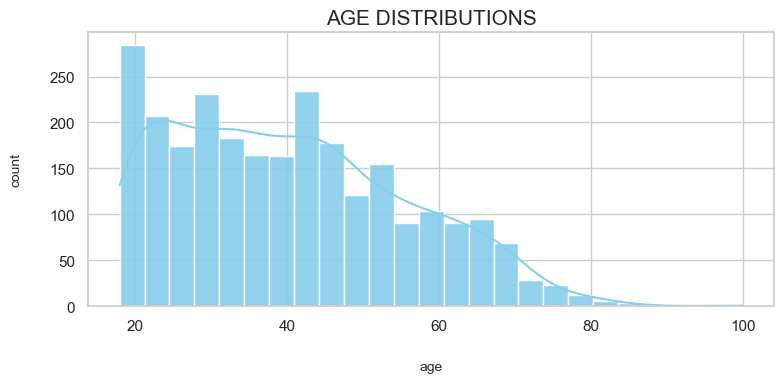

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,4))
sns.histplot(data=df,x="age",bins=25,kde=True,color="skyblue",alpha=0.9)
plt.title("AGE DISTRIBUTIONS", fontsize=15)
plt.xlabel("age",fontsize=10,labelpad=20)
plt.ylabel("count",fontsize=10,labelpad=20)
plt.tight_layout()
plt.savefig("age distributions.png",dpi=100,bbox_inches="tight")
plt.show()

In [29]:
df["age"].describe()

count    2615.000000
mean       40.294455
std        15.272772
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max       100.000000
Name: age, dtype: float64

#### **INSIGHTS**

**Age Overview:** The dataset has a mean age of 40.29 and a median age of 39.0,These numbers are very close,showing a balanced distribution.

**Age Range:** The population ranges from 18 to 100 years old.But most of the people are younger or middle aged

**Key Findings:** 50% of the participants are between the ages 27 and 51 years old.This is the main group of our dataset

**Trends:** While we have people up to 100 years old there are very few people after age 60.This creates a "tail" on the right side of our graph

**Outliers:** The maximum age of 100 is an extreme value.However, we had previously looked at this with a boxplot and identified it as an outlier and included it in the analysis. Since it is a single value, it does not disrupt the analysis.

In [30]:
#GENDER DISTRIBUTION
#This analysis shows the number of male and female respondent in the dataset

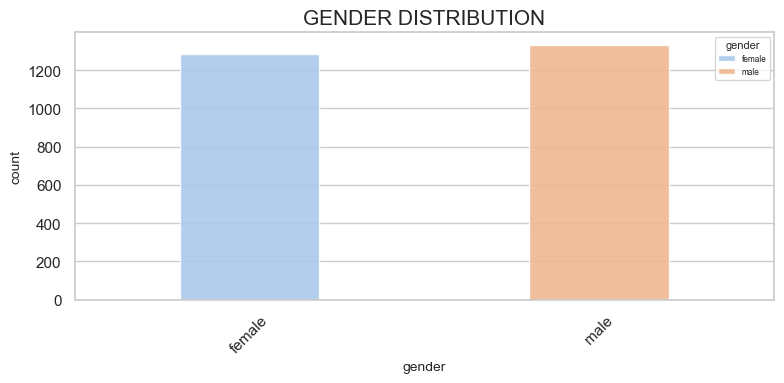

In [31]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="gender_label",hue="gender_label",palette="pastel",alpha=0.9,width=0.4,legend=True)
plt.title("GENDER DISTRIBUTION",fontsize=15)
plt.xlabel("gender",fontsize=10)
plt.ylabel("count",fontsize=10)
plt.legend(title="gender",title_fontsize=8,prop={"size":6},loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("gender distribution.png",dpi=100,bbox_inches="tight")
plt.show()

In [32]:
count=df["gender_label"].value_counts()
print(count)
percent=df["gender_label"].value_counts(normalize=True)*100
print(percent)

gender_label
male      1331
female    1284
Name: count, dtype: int64
gender_label
male      50.898662
female    49.101338
Name: proportion, dtype: float64


**INSIGHTS** 

**Gender Balance:** The dataset has a very balanced distribution between male (50.89%) and female (49.10%) participants

**Sample Size:** With 1331 males and 1284 females, the group are nearly equal.This ensures that our gender-based analysis will be fair and wont have a significant bias

In [33]:
#EDUCATION DISTRIBUTION
#This analysis shows the distribution of education levels distribution the participants.

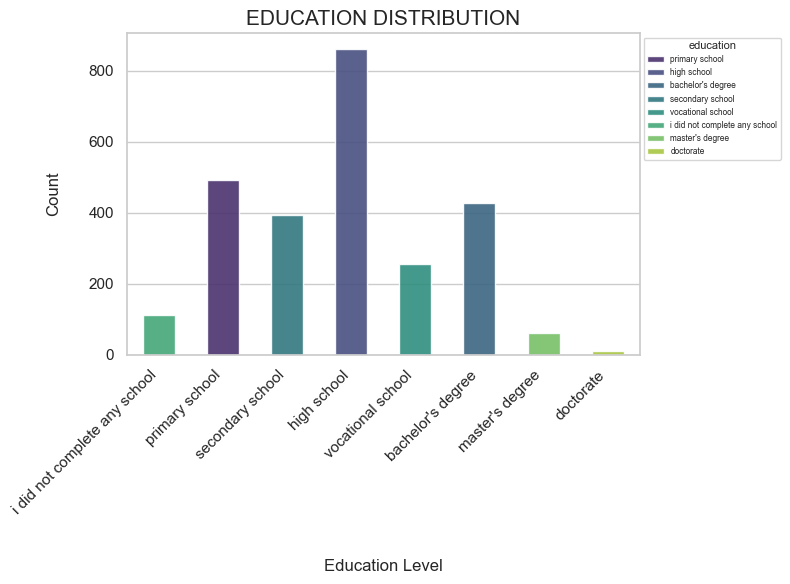

In [34]:
edu_order=["i did not complete any school","primary school","secondary school","high school","vocational school","bachelor's degree","master's degree","doctorate"]
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.countplot(data=df,x="degree_label",hue="degree_label",palette="viridis",alpha=0.9,width=0.5,legend=True,order=edu_order)
plt.title("EDUCATION DISTRIBUTION",fontsize=15)
plt.xlabel("Education Level",fontsize=12,labelpad=30)
plt.ylabel("Count",fontsize=12,labelpad=20)
plt.legend(title="education",title_fontsize=8,prop={"size":6},loc="upper left",bbox_to_anchor=(1,1))
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.savefig("education distribution.png",dpi=100,bbox_inches="tight")
plt.show()

In [35]:
edu_count=df["degree_label"].value_counts()
print(edu_count)
edu_percent=df["degree_label"].value_counts(normalize=True)*100
print(edu_percent)

degree_label
high school                      862
primary school                   492
bachelor's degree                427
secondary school                 395
vocational school                255
i did not complete any school    113
master's degree                   61
doctorate                         10
Name: count, dtype: int64
degree_label
high school                      32.963671
primary school                   18.814532
bachelor's degree                16.328872
secondary school                 15.105163
vocational school                 9.751434
i did not complete any school     4.321224
master's degree                   2.332696
doctorate                         0.382409
Name: proportion, dtype: float64


**INSIGHT**

**Most Common Level:** The majority of the participants are high school graduates,making up about 32.96%(862 people) of the dataset.Primary school graduates are the second largest group with 18.81%

**Higher Education and Non-school:** There is a small number of people with advanced degrees.Master's degree holders are only 2.33% and doctorate  holders are less than 1%(0.38%).This shows that the dataset mostly represents people with basic and secondary education level.Also interestingly there are more people who did not complete any school (4.32%)

**Other Groups:** Vocational school and Bachelor's degree groups are also significant,representing around 9.75% and 16.32% respectively.

In [36]:
#SETTLEMENT DISTRIBUTION
#This analysis shows the distribution of participants in our data set according to their place of residence size.

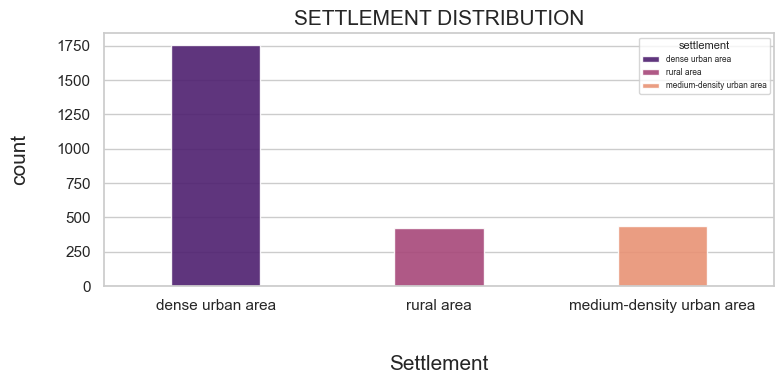

In [37]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="degurba_label",hue="degurba_label",palette="magma",alpha=0.9,width=0.4,legend=True)
plt.title("SETTLEMENT DISTRIBUTION",fontsize=15)
plt.xlabel("Settlement",fontsize=15,labelpad=30)
plt.ylabel("count",fontsize=15,labelpad=20)
plt.legend(title="settlement",title_fontsize=8,prop={"size":6},loc="upper right")
plt.tight_layout()
plt.savefig("settlement distribution.png",dpi=100,bbox_inches="tight")
plt.show()

In [38]:
set_count=df["degurba_label"].value_counts()
print(set_count)
set_percent=df["degurba_label"].value_counts(normalize=True)*100
print(set_percent)

degurba_label
dense urban area             1753
medium-density urban area     436
rural area                    426
Name: count, dtype: int64
degurba_label
dense urban area             67.036329
medium-density urban area    16.673040
rural area                   16.290631
Name: proportion, dtype: float64


**INSIGHT**

-The majority of the participants live in "dense urban area",accounting for 67% of the total dataset

-Rural area and medium density urban area have almost equal represantation ,with approximately 16% each

-The means our data mostly reflects people living in big cities.We should consider this when we analyze income and education levels later

In [39]:
#BIVARIATE ANALYSIS

**In this part of my project, I will examine the relationship between different variables.I will focus on the following  five comparisons:**

*Gender vs. Education Level

*Age vs. Education Level

*Income vs. Education Level

*Settlement vs. Education Level

*Gender vs. Income


In [40]:
#GENDER & EDUCATION LEVEL DISTRIBUTION

In this first part of my bivariate analysis , I want to see if there is a relationship between gender and education level.I will check if one gender has a higher level of education compared to the other in this dataset 

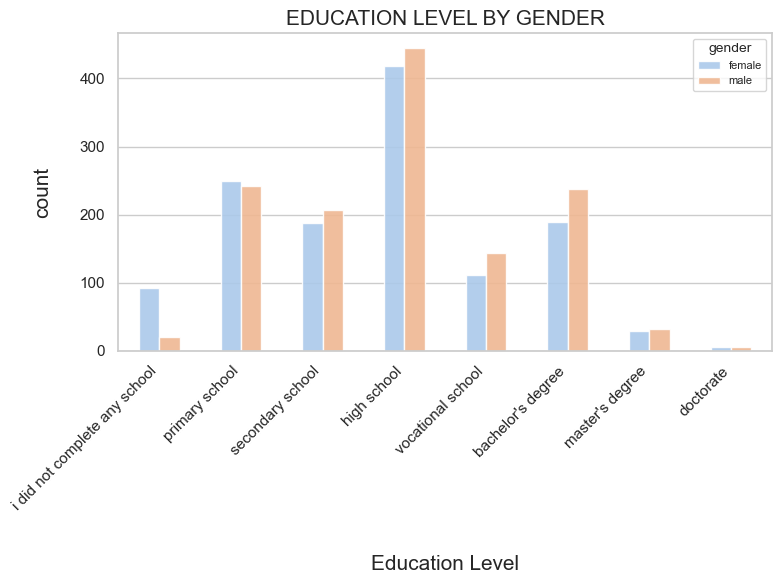

In [41]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.countplot(data=df,x="degree_label",hue="gender_label",palette="pastel",alpha=0.9,width=0.5,legend=True,order=edu_order)
plt.title("EDUCATION LEVEL BY GENDER",fontsize=15)
plt.xlabel("Education Level",fontsize=15,labelpad=30)
plt.ylabel("count",fontsize=15,labelpad=20)
plt.xticks(rotation=45,ha="right")
plt.legend(title="gender",title_fontsize=10,prop={"size":8},bbox_to_anchor=(1,1),loc="upper right")
plt.tight_layout()
plt.savefig("gender & education level bivariate analysis.png",dpi=100,bbox_inches="tight")
plt.show()

In [42]:
gender_edu_count=df.groupby(["gender_label","degree_label"]).size().unstack()
print(gender_edu_count)

degree_label  bachelor's degree  doctorate  high school  \
gender_label                                              
female                      189          5          418   
male                        238          5          444   

degree_label  i did not complete any school  master's degree  primary school  \
gender_label                                                                   
female                                   93               29             250   
male                                     20               32             242   

degree_label  secondary school  vocational school  
gender_label                                       
female                     188                112  
male                       207                143  


In [43]:
gender_edu_percent=pd.crosstab(df["gender_label"],df["degree_label"],normalize="index")*100
print(gender_edu_percent)

degree_label  bachelor's degree  doctorate  high school  \
gender_label                                              
female                14.719626   0.389408    32.554517   
male                  17.881292   0.375657    33.358377   

degree_label  i did not complete any school  master's degree  primary school  \
gender_label                                                                   
female                             7.242991         2.258567       19.470405   
male                               1.502630         2.404207       18.181818   

degree_label  secondary school  vocational school  
gender_label                                       
female               14.641745           8.722741  
male                 15.552216          10.743802  


In [44]:
df["gender_label"].value_counts()

gender_label
male      1331
female    1284
Name: count, dtype: int64



**INSIGHT**

**-Balanced Sample:** The dataset is well-balanced with 1331 male and 1284 female participants.This makes the comparison more reliable

**-Higher Education:** Men have a slightly higher representation in higher education.Specifically, 17.8% of men have a Bachelor's degree compared to 14.7% of women

**-No Formal Schooling:** There is a significant  gap in the "no school"category.The rate for women (7.2%) is nearly five times higher than for men(1.5%)

**-Advanced Degrees:** At the doctorate level, the numbers are equal(5 participants each),showing that gender representation is balanced at the highest academic level.

**-SUMMARY:** Overall, while the distribution is similar in most categories,men in this dataset tend to have a slightly higher rate of university level education



In [45]:
#AGE & EDUCATION LEVEL DISTRIBUTION

In this section of my bivariate analysis, I wanted to compare the age distribution by education level and identify any demographic differences between groups by examining outlier values.

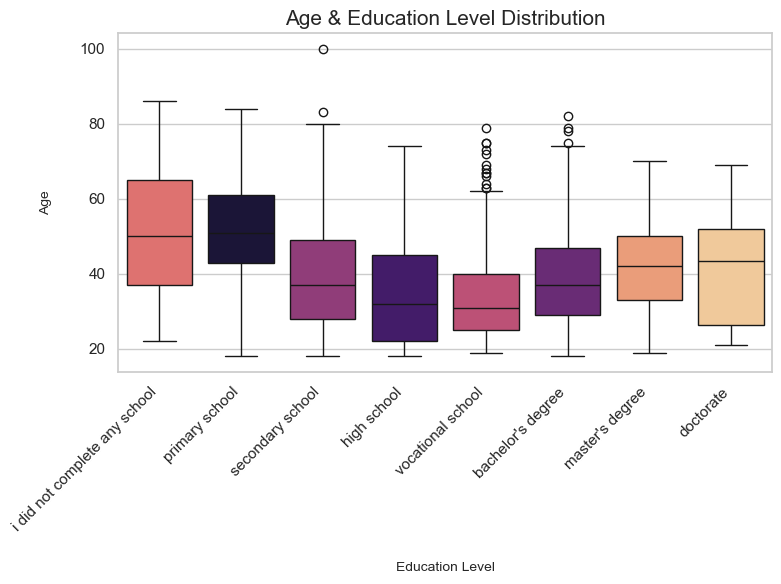

In [46]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x="degree_label",y="age",palette="magma",hue="degree_label",legend=False,order=edu_order)
plt.title("Age & Education Level Distribution",fontsize=15)
plt.xlabel("Education Level",fontsize=10,labelpad=20)
plt.ylabel("Age",fontsize=10,labelpad=20)
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.savefig("Age & Education Level Distribution",dpi=100,bbox_inches="tight")
plt.show()

In [47]:
age_edu_count=df.groupby("degree_label")["age"].describe()
print(age_edu_count)

                               count       mean        std   min    25%   50%  \
degree_label                                                                    
bachelor's degree              427.0  39.353630  13.277076  18.0  29.00  37.0   
doctorate                       10.0  41.600000  16.063762  21.0  26.25  43.5   
high school                    862.0  34.786543  14.318378  18.0  22.00  32.0   
i did not complete any school  113.0  52.168142  16.799183  22.0  37.00  50.0   
master's degree                 61.0  41.721311  12.156111  19.0  33.00  42.0   
primary school                 492.0  51.544715  12.313291  18.0  43.00  51.0   
secondary school               395.0  39.184810  14.686012  18.0  28.00  37.0   
vocational school              255.0  34.847059  13.007726  19.0  25.00  31.0   

                                75%    max  
degree_label                                
bachelor's degree              47.0   82.0  
doctorate                      52.0   69.0  
high scho

**INSIGHT**

while we generally expect age to increase with higher academic degrees (master/doctorate)our data shows a different trend for lower education levels:

**-Genaerational Gap:** Participants who "did not complate any school"(median age :50) and those with "primary school"(median age:51) education are the oldest groups in this dataset

**-Historical Context:** This suggest a "Generational Effect."In oldest generations, access to formal education was more limited.Therefore,the senior participants in our data often have lower formal education levels compared to the younger generations.

**-The "U-Shape" Trend:** We see a "u-shaped" distribution:age is high at the lower education levels,drop significantly for "Vocational School"(median age:31),and "high school"(median age:32) and then rises again for  "master/doctorate" due to the time required for advanced specialization.

In [48]:
#INCOME SCORE & EDUCATION DISTRIBUTION

In this section of my bivariate analysis, I want to explore if there is a relationship between income score and education level. I objectives examine the effect of education on income score.

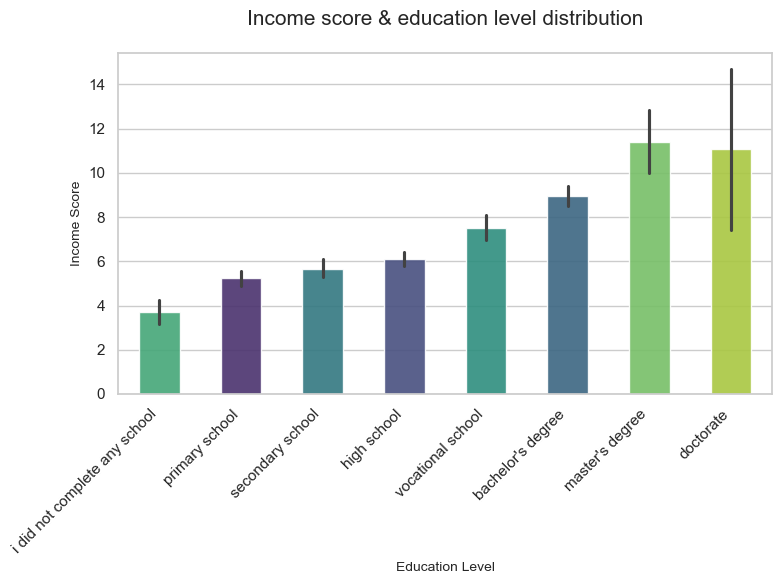

In [49]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(data=df,x="degree_label",y="income",hue="degree_label",palette="viridis",alpha=0.9,width=0.5,order=edu_order,legend=False)
plt.title("Income score & education level distribution",fontsize=15,pad=20)
plt.xlabel("Education Level",fontsize=10)
plt.ylabel("Income Score",fontsize=10)
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.savefig("Income score & education level distribution.png",dpi=100,bbox_inches="tight")
plt.show()

In [50]:
income_edu_count=df.groupby("degree_label")["income"].describe()
print(income_edu_count)

                               count       mean       std  min  25%   50%  \
degree_label                                                                
bachelor's degree              415.0   8.949398  4.980139  1.0  5.0  10.0   
doctorate                       10.0  11.100000  6.332456  1.0  5.5  13.5   
high school                    843.0   6.107948  4.374833  1.0  2.0   6.0   
i did not complete any school  113.0   3.690265  3.035738  1.0  1.0   3.0   
master's degree                 61.0  11.393443  5.616282  1.0  8.0  12.0   
primary school                 483.0   5.240166  3.852612  1.0  1.0   5.0   
secondary school               383.0   5.671018  4.282116  1.0  1.0   5.0   
vocational school              247.0   7.518219  4.578879  1.0  3.0   8.0   

                                75%   max  
degree_label                               
bachelor's degree              13.0  23.0  
doctorate                      15.5  19.0  
high school                     9.0  23.0  
i did not

**INSIGHT**

While the bar chart illustrates a general upward trend, a closer look at the descriptive statistics (mean vs. median) reveals a more nuanced socia-economic story:

**-The Higher Education Premium:** There is a significant structural jump in income when moving from High School to a Bachelor's Degree.This confirms that a university degree is a primary driver of economic mobility in this dataset.

**-Advanced Degrees(Master's vs. Doctorate):** Although the means are similar,the median income for doctorate holders (13.5) is notably higher than for master's holders(12.0).This suggest that while the "avarage" is similar,the majority of PhD graduates sit in a higher income bracket.

**-Lower Education Tiers:** Individuals with no formal schooling consistently occupy the lowest income tier.There is no statistically significant difference in income between primary and secondary school graduates,as both their means and medians remain close.

**-Sample Size Observation:** The high variance in the Doctorate category is linked to the small sample size(n=10) This explains the larger error bars seen in the visualizations.

In [51]:
#SETTLEMENT VS. EDUCATION LEVEL DISTRIBUTION

In this section of my bivariate analysis, I will examine whether there is a relationship between place of residence and education level. I aim to investigate how individuals' education levels affect their settlement

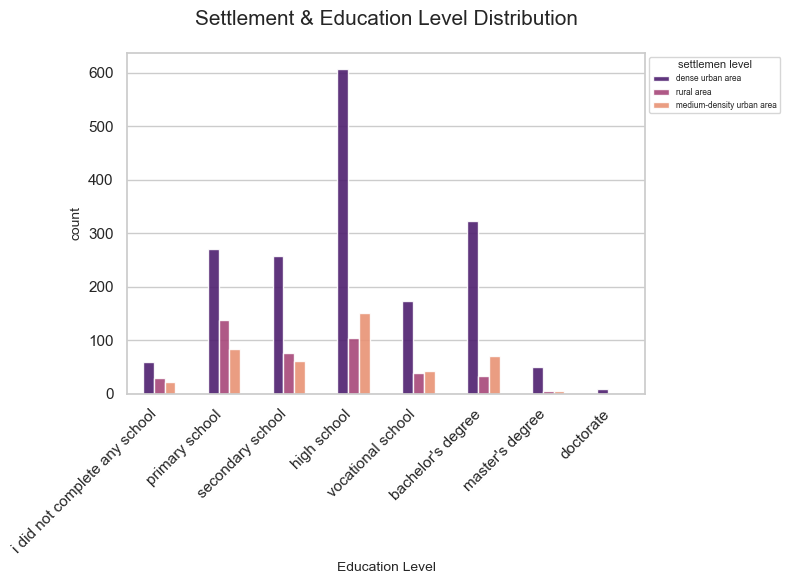

In [52]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.countplot(data=df,x="degree_label",hue="degurba_label",palette="magma",alpha=0.9,width=0.5,legend=True,order=edu_order)
plt.title("Settlement & Education Level Distribution",fontsize=15,pad=20)
plt.xlabel("Education Level",fontsize=10)
plt.ylabel("count",fontsize=10)
plt.xticks(rotation=45,ha="right")
plt.legend(title="settlemen level",title_fontsize=8,prop={"size":6},bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.savefig("Settlement & Education Level Distribution.png",dpi=100,bbox_inches="tight")
plt.show()

In [53]:
set_edu_count=df.groupby(["degree_label","degurba_label"]).size().unstack()
#Since no PhD graduates were observed in the rural & medium area , the resulting NaN values were filled in with (0) for table formatting purposes.
set_edu_count=set_edu_count.fillna(0)
print(set_edu_count)

degurba_label                  dense urban area  medium-density urban area  \
degree_label                                                                 
bachelor's degree                         324.0                       70.0   
doctorate                                  10.0                        0.0   
high school                               607.0                      151.0   
i did not complete any school              60.0                       23.0   
master's degree                            51.0                        5.0   
primary school                            270.0                       84.0   
secondary school                          258.0                       61.0   
vocational school                         173.0                       42.0   

degurba_label                  rural area  
degree_label                               
bachelor's degree                    33.0  
doctorate                             0.0  
high school                         104.0  

In [54]:
set_edu_percent=pd.crosstab(df["degree_label"],df["degurba_label"],normalize="index")*100
set_edu_percent=set_edu_percent.fillna(0)
print(set_edu_percent)

degurba_label                  dense urban area  medium-density urban area  \
degree_label                                                                 
bachelor's degree                     75.878220                  16.393443   
doctorate                            100.000000                   0.000000   
high school                           70.417633                  17.517401   
i did not complete any school         53.097345                  20.353982   
master's degree                       83.606557                   8.196721   
primary school                        54.878049                  17.073171   
secondary school                      65.316456                  15.443038   
vocational school                     67.843137                  16.470588   

degurba_label                  rural area  
degree_label                               
bachelor's degree                7.728337  
doctorate                        0.000000  
high school                     12.064965  

**INSIGHT**

**-Urban Concentration:** High level academic degrees(master's and doctorate) are heavily concentrated in Dense Urban Areas.In this dataset 100% of PhD holders reside in major cities,indicating a significant clustering of highly skilled labor in urban centers.

**-Rural Education Gap:** There is a clear decline in higher education levels as population density decreases.While bachelor's degrees are common in cities,they drop significantly in rural areas(~7%) where no Doctorate holders are observed.

**-Educational Distribution:** Primary and secondary education levels show a more balanced distribution across all settlement types.This suggests that while basic education is accessible everywhere,advanced education remains a geographical privilege

**RESULT**

"The data reveals a strong correlation between settlement type and education level.The fact that advanced degrees are almost exclusively found in urban areas highlights a clear geographic disparity and suggest a "brain drain" towards major cities."

In [55]:
#GENDER VS. INCOME SCORE DISTRIBUTION

In this final section of my bivariate analysis, I will examine whether there is a relationship between gender and income level score. My aim is to investigate whether individuals' income scores differ based on their gender.

In this final section of my bivariate analysis, I will examine whether there is a relationship between gender and income level score. My aim is to investigate whether individuals' income scores differ based on their gender.

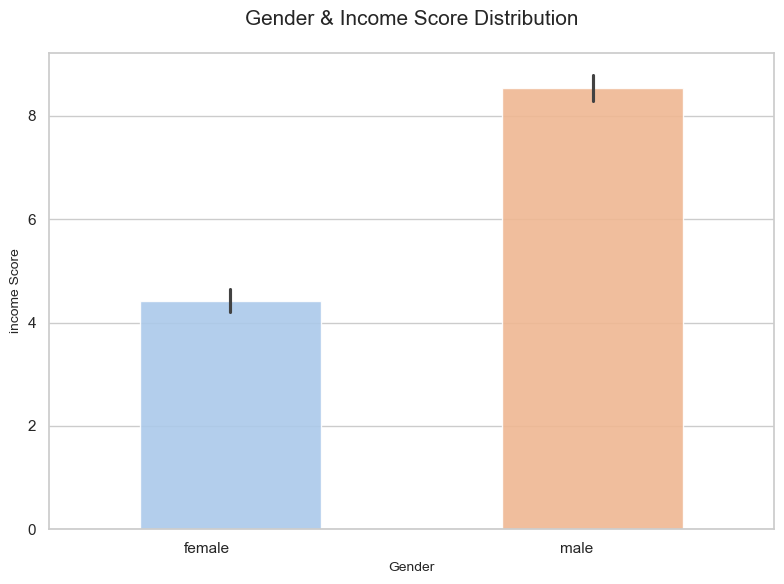

In [56]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(data=df,x="gender_label",y="income",hue="gender_label",palette="pastel",alpha=0.9,width=0.5,legend=False)
plt.title("Gender & Income Score Distribution",fontsize=15,pad=20)
plt.xlabel("Gender",fontsize=10)
plt.ylabel("income Score",fontsize=10)
plt.xticks(ha="right")
plt.tight_layout()
plt.savefig("Gender & Income Score Distribution.png",dpi=100,bbox_inches="tight")
plt.show()

In [57]:
gender_income_count=df.groupby("gender_label")["income"].describe()
print(gender_income_count)

               count      mean       std  min  25%  50%   75%   max
gender_label                                                       
female        1257.0  4.420843  3.927728  1.0  1.0  3.0   8.0  20.0
male          1298.0  8.543143  4.410166  1.0  5.0  9.0  11.0  23.0


**INSIGHT**

**-Significant Income Gap:** The avarage income for male individuals (8.54) is nearly **twice as high** as for female individuals(4.42).

**-Median Difference:** The difference is even more evident in the median (50%).While the median income for men is 9.0,it is only 3.0 for women.This suggests that the majority of women are clustered in lower-income brackets

**-Distribution & Inequality:** Even the top %25 (75 percentile) of women earn less(8.0) than the average man (8.54).This visual and statistical evidence points to a clear **"Gender Pay Gap"** within the dataset

In [58]:
# THE OPPORTUNITY GAP SUBPLOT

In this part of my analysis, I want to examine with a subplot graph the effect of education level on income level on one side, and the effect of gender on income level on the other side.Thus, I aim to show side by side the two main sources of income inequality, which are the results of these two analyses we conducted separately in the previous section.

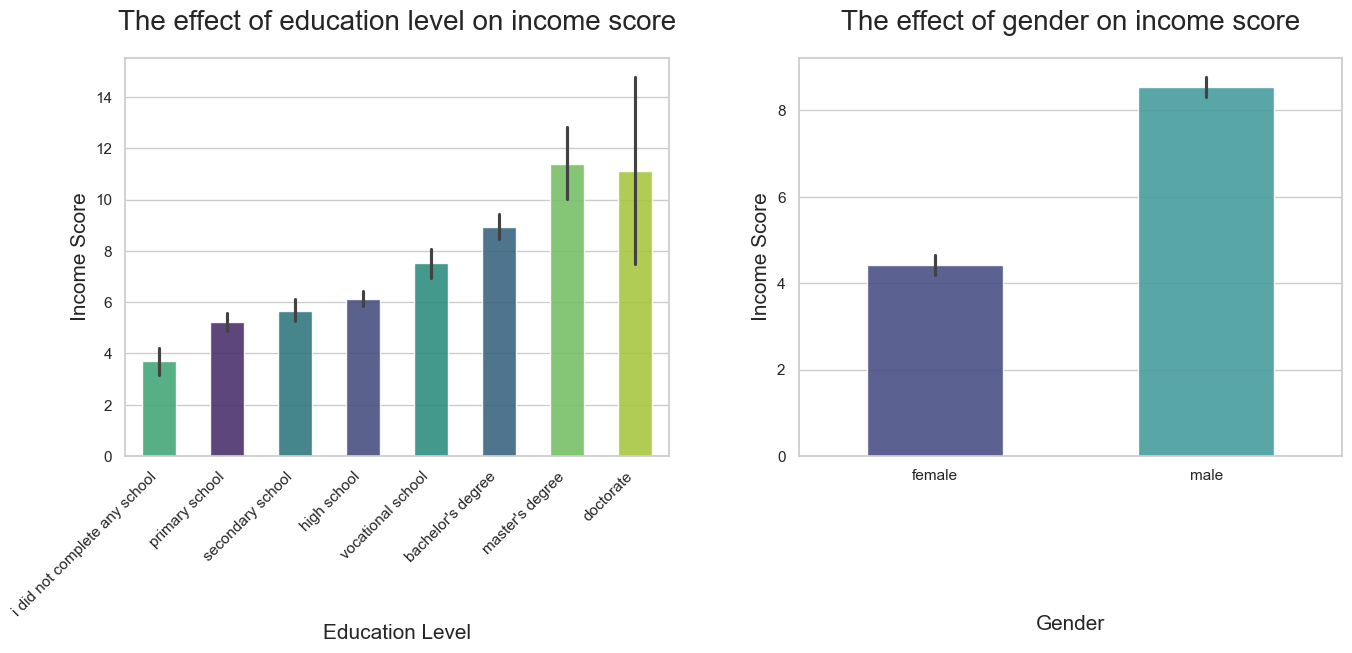

In [59]:
fig,ax=plt.subplots(1,2,figsize=(15,8))
sns.barplot(data=df,x="degree_label",y="income",hue="degree_label",palette="viridis",alpha=0.9,width=0.5,legend=False,order=edu_order,ax=ax[0])
ax[0].set_title("The effect of education level on income score",fontsize=20,pad=20)
ax[0].set_xlabel("Education Level",fontsize=15)
ax[0].set_ylabel("Income Score",fontsize=15)
ax[0].tick_params(axis="x",rotation=45)
ax[0].set_xticks(range(len(df["degree_label"].unique())))
#I used unique() and set_xticks to fix label positions.This prevents "userwarning" and unsures labels match the bars perfectly
ax[0].set_xticklabels(ax[0].get_xticklabels(),ha="right")

sns.barplot(data=df,x="gender_label",y="income",hue="gender_label",palette="mako",alpha=0.9,width=0.5,legend=False,ax=ax[1])
ax[1].set_title("The effect of gender on income score",fontsize=20,pad=20)
ax[1].set_xlabel("Gender",fontsize=15,labelpad=95)
ax[1].set_ylabel("Income Score",fontsize=15)
ax[1].tick_params(axis="x",rotation=0)
plt.tight_layout(pad=5.0)
plt.savefig("THE OPPORTUNITY GAP SUBPLOT.png",dpi=100,bbox_inches="tight")
plt.show()


**FINAL CONCLUSION**

**-Education:** As the education level goes up,the income score also increases.This shows that education is very important for a better salary.

**-Gender:** There is a clear difference between men and women.Men's average income is higher in this dataset.

**-Overall:** Even with the same education,gender is still a strong factor.This subplot summarizes my main finding from the previous sections and shows the "**Opportunity Gap**" clearly.